In [1]:
import pandas as pd
dt = pd.read_csv('19.csv')

dt.head()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
0,1,28773,Ca-A Cancer Journal for Clinicians,journal,"15424863, 00079235","62,937",Q1,168,47,119,3452,15499,80,126.34,73.45,United States,Northern America,Wiley-Blackwell,1950-2020,Hematology (Q1); Oncology (Q1)
1,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601","40,949",Q1,143,10,9,1292,492,9,50.00,129.20,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2020,Epidemiology (Q1); Health Information Manageme...
2,3,18991,Nature Reviews Genetics,journal,"14710056, 14710064","26,214",Q1,365,106,325,7332,6348,149,21.22,69.17,United Kingdom,Western Europe,Nature Publishing Group,2000-2020,Genetics (Q1); Genetics (clinical) (Q1); Molec...
3,4,21318,Nature Reviews Immunology,journal,"14741741, 14741733","20,529",Q1,390,230,436,9421,8200,202,17.33,40.96,United Kingdom,Western Europe,Nature Publishing Group,2001-2020,Immunology (Q1); Immunology and Allergy (Q1); ...
4,5,71056,MMWR. Surveillance summaries : Morbidity and m...,journal,"15458636, 15460738","19,961",Q1,100,32,48,499,2235,48,57.77,15.59,United States,Northern America,Centers for Disease Control and Prevention (CDC),2002-2020,Epidemiology (Q1); Health Information Manageme...


In [2]:
import numpy as np

def clean_dataset(dt):
    assert isinstance(dt, pd.DataFrame), "dt needs to be a pd.DataFrame"
    dt.dropna(inplace=True)
    indices_to_keep = ~dt.isin([np.nan, np.inf, -np.inf]).any(1)
    return dt[indices_to_keep].astype(np.float64)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [4]:
#attribut selection
X = dt.iloc[:,[7, 8, 9, 10, 11, 12, 13, 14]].values
y = dt.iloc[:,6].values

In [5]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state=10)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
#define cross-validation method to use
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [8]:
#used model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn import model_selection

In [9]:
dtc = DecisionTreeClassifier
model1 = BaggingClassifier(estimator=dtc(max_depth=10), n_estimators=500, random_state=0)

model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)


In [10]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', StandardScaler()), ('model', model1)])
result = cross_val_score(pipe, X, y, cv=cv)

In [11]:
result.mean()

np.float64(0.7358483869118743)

In [12]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[389, 134,   2,   0],
       [ 82, 324,  70,   6],
       [ 14, 109, 312,  55],
       [  1,   3,  66, 453]])

In [13]:
from sklearn.metrics import classification_report
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n          Q1       0.80      0.74      0.77       525\n          Q2       0.57      0.67      0.62       482\n          Q3       0.69      0.64      0.66       490\n          Q4       0.88      0.87      0.87       523\n\n    accuracy                           0.73      2020\n   macro avg       0.74      0.73      0.73      2020\nweighted avg       0.74      0.73      0.73      2020\n'

In [14]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, output_dict=True)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.7316831683168317


In [15]:
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']

print(precision)
print(recall)

0.7358722164492751
0.7290107581793299


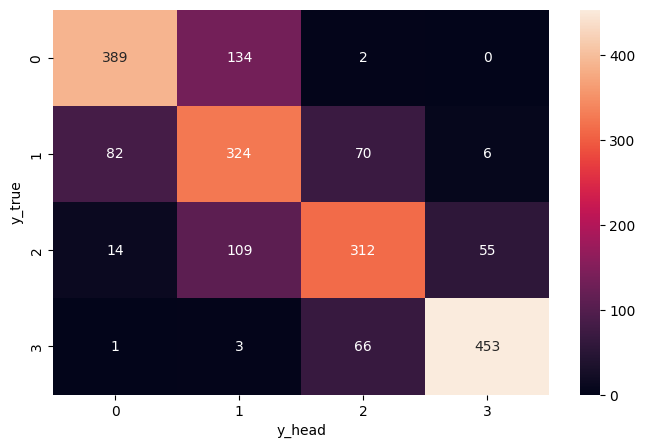

In [16]:
f, ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".0f", ax=ax)
plt.xlabel("y_head")
plt.ylabel("y_true")
plt.show()

In [17]:
!pip install yellowbrick

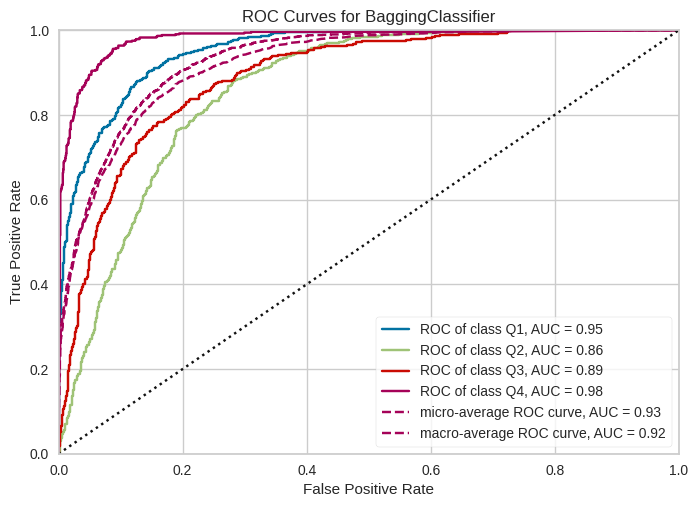

<Figure size 800x550 with 0 Axes>

In [18]:
from yellowbrick.classifier.rocauc import roc_auc
roc_auc(model1, X_train, y_train, X_test=X_test, y_test=y_test)
plt.savefig('roc_auc.png')